# Stage 4. Dual-Path Feature Extraction

Notebook ini mengekstrak fitur hand-crafted warna dan deep embedding ResNet18-CSA dari ROI fingertip/nail yang sudah dinormalisasi pada stage sebelumnya, memakai modul src.common.features yang sama persis dengan situs konjungtiva dan palm karena modul tersebut situs-agnostik. Backbone dipakai sebagai frozen feature extractor, tanpa stage fine-tune end-to-end terpisah pada tahap ini.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import features

output_dir = paths.outputs_dir("nail")
manifest = pd.read_csv(output_dir / "manifest.csv")
manifest = manifest[manifest["roi_precropped"]].reset_index(drop=True)
print("sampel dengan ROI", len(manifest))

sampel dengan ROI 803


## Handcrafted Color Features

Fitur mencakup statistik RGB, rasio terkait hemoglobin, statistik HSV dan CIELAB, erythema index, tekstur gray level, dan entropy, dihitung hanya pada pixel valid hasil normalisasi Stage 2 dan 3.

In [2]:
handcrafted = features.extract_handcrafted_features(manifest)
handcrafted.head()

,uid,mean_r,mean_g,mean_b,mean_r_minus_g,hhr,hhr_hue,red_ratio,erythema_index,mean_h,...,std_a,mean_bb,std_bb,g1,g2,g3,g4,g5,entropy,brightness
0,nail_ID001,184.736496,130.192139,135.352966,54.544357,1.418953,0.617874,0.410269,0.291955,0.694801,...,4.998374,133.915909,3.945250,7.924646,6.930242,0.341136,4.848825,147.079437,6.820129,147.079436
1,nail_ID003,166.533737,107.958435,102.928658,58.575302,1.542573,0.231410,0.441242,0.373283,0.264317,...,3.672320,140.817429,6.308511,9.381437,9.182303,0.251766,5.985942,124.896179,7.006529,124.896177
2,nail_ID004,182.078476,125.678978,122.822746,56.399498,1.448758,0.266882,0.422868,0.307277,0.274803,...,3.916175,138.631729,4.904290,8.185777,7.365394,0.291980,5.051730,142.218628,6.725955,142.218629
3,nail_ID005,180.251099,126.873627,130.571106,53.377472,1.420714,0.402584,0.411818,0.303168,0.511851,...,4.237474,134.503540,4.718739,8.418716,7.563161,0.329414,5.225926,143.250748,6.650891,143.250743
4,nail_ID006,170.422226,108.190620,108.520256,62.231606,1.575203,0.292074,0.440216,0.372350,0.323142,...,4.255624,138.421097,5.054001,8.283664,7.800729,0.219018,5.191455,126.834534,6.638680,126.834531


## Correlation with Hemoglobin

Korelasi fitur hand-crafted kunci terhadap hemoglobin memverifikasi arah hubungan sesuai fisika optik, yaitu makin rendah hemoglobin makin sedikit absorpsi merah sehingga red_ratio dan mean_a (redness CIELAB) turun. Sinyal warna nail bed diketahui lebih noisy dibanding konjungtiva berdasarkan riset literatur, sehingga korelasi di sini wajar lebih lemah.

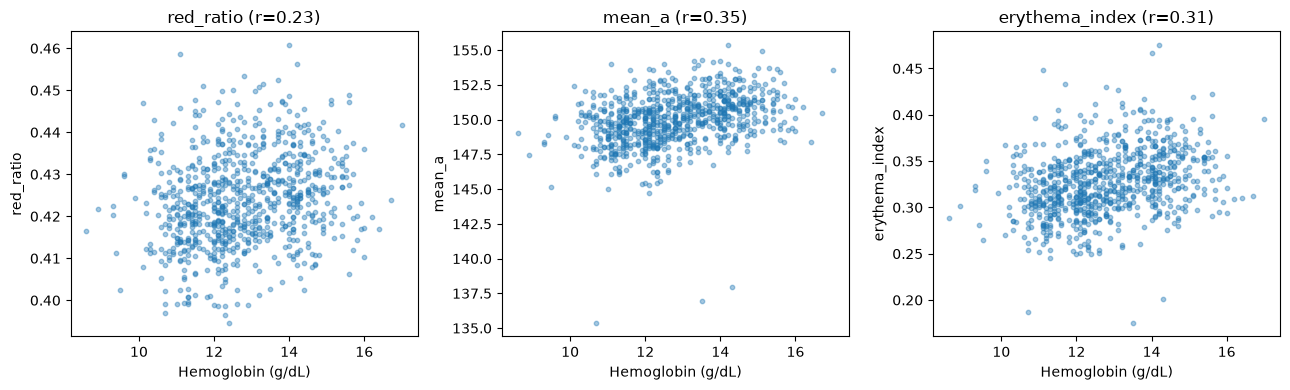

In [3]:
merged = manifest[["uid", "hb_gdl"]].merge(handcrafted, on="uid")
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, column in zip(axes, ["red_ratio", "mean_a", "erythema_index"]):
    ax.scatter(merged["hb_gdl"], merged[column], alpha=0.4, s=10)
    ax.set_xlabel("Hemoglobin (g/dL)")
    ax.set_ylabel(column)
    correlation = merged["hb_gdl"].corr(merged[column])
    ax.set_title(f"{column} (r={correlation:.2f})")
plt.tight_layout()
plt.show()

## Deep Embedding Extraction

Embedding ResNet18-CSA diekstrak sebagai fitur statis dengan bobot backbone pralatih ImageNet, dipakai apa adanya (frozen) sebagai bagian dari vektor fusi pada training multi-task stage berikutnya.

In [4]:
backbone = features.EmbeddingBackbone(backbone_name="resnet18")
deep_embeddings, embedding_uids = features.extract_deep_embeddings(manifest, model=backbone)
print("embedding shape", deep_embeddings.shape)

embedding shape (803, 256)


## Fusion Attention Demonstration

Verifikasi bentuk vektor fusi (handcrafted terstandardisasi, deep embedding, demografi, dan site token) sesuai kontrak yang dipakai src.common.train.run_kfold pada stage berikutnya. polish_flag belum dimasukkan ke vektor fusi pada tahap ini karena build_fusion_input bersifat situs-agnostik, keputusan memasukkannya sebagai fitur kategorikal tambahan dilaporkan terpisah untuk validasi sebelum stage training.

In [5]:
fusion_input = features.build_fusion_input(handcrafted, deep_embeddings, manifest)
print("fusion input shape", fusion_input.shape)

fusion input shape (803, 286)


## Save Features

In [6]:
saved_paths = features.save_features(handcrafted, deep_embeddings, embedding_uids, output_dir=output_dir)
saved_paths

{'handcrafted': '/home/praktikan/projects/Azril/hemavision/outputs/nail/handcrafted_features.csv',
 'embeddings': '/home/praktikan/projects/Azril/hemavision/outputs/nail/deep_embeddings.npy',
 'uids': '/home/praktikan/projects/Azril/hemavision/outputs/nail/deep_embeddings_uids.csv'}